In [ ]:
import os, sys, io, re, json, time, math, base64, random, hashlib, subprocess, warnings
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

CFG = dict(
    REPO            = "moonshotai/PerceptionBench",
    SPLIT           = "train",

    N_PER_CATEGORY  = 12,
    MAX_SCAN        = 1200,
    SEED            = 0,

    LOAD_MODE       = "stream",

    BACKEND         = "blind",

    API_BASE        = os.environ.get("PB_API_BASE", "https://api.openai.com/v1"),
    API_KEY         = os.environ.get("PB_API_KEY", ""),
    API_MODEL       = os.environ.get("PB_API_MODEL", "gpt-4o-mini"),
    API_WORKERS     = 4,
    API_MAX_TOKENS  = 512,

    LOCAL_MODEL     = "HuggingFaceTB/SmolVLM2-2.2B-Instruct",
    LOCAL_MAX_NEW   = 128,

    MAX_IMAGE_SIDE  = 1024,
    JPEG_QUALITY    = 90,

    JUDGE           = "rule",
    NUM_REL_TOL     = 0.0,

    OUT_DIR         = "/content/perceptionbench_out" if os.path.isdir("/content") else "./perceptionbench_out",
    INSTALL_DEPS    = True,
    SHOW_PLOTS      = True,
)

random.seed(CFG["SEED"])
os.makedirs(CFG["OUT_DIR"], exist_ok=True)


def _sh(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs],
                   check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)


if CFG["INSTALL_DEPS"]:
    print("[setup] installing dependencies (quiet, ~30s on a cold Colab)…")
    _sh(["datasets>=3.0.0", "huggingface_hub>=0.25.0", "pillow", "pandas",
         "numpy", "matplotlib", "requests", "pyarrow"])
    if CFG["BACKEND"] == "local":
        _sh(["transformers>=4.51.0", "accelerate", "torch", "num2words"])

import numpy as np
import pandas as pd
import requests
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image

matplotlib.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                            "grid.alpha": .25, "axes.spines.top": False,
                            "axes.spines.right": False})
print("[setup] ready\n")

In [ ]:
def _iter_rows(repo, split, mode, max_scan):
    """Yield dict rows, trying progressively heavier strategies."""
    from datasets import load_dataset

    if mode == "full":
        print("[load] full download (~1.63 GB) …")
        ds = load_dataset(repo, split=split)
        for i, r in enumerate(ds):
            if i >= max_scan:
                return
            yield r
        return

    try:
        from huggingface_hub import HfApi, hf_hub_url
        api = HfApi()
        files = api.list_repo_files(repo, repo_type="dataset", revision="refs/convert/parquet")
        pq = sorted(f for f in files if f.endswith(".parquet") and f"/{split}/" in f)
        if pq:
            urls = [hf_hub_url(repo, f, repo_type="dataset", revision="refs/convert/parquet") for f in pq]
            print(f"[load] streaming {len(urls)} parquet shard(s) from refs/convert/parquet")
            ds = load_dataset("parquet", data_files=urls, split="train", streaming=True)
            for i, r in enumerate(ds):
                if i >= max_scan:
                    return
                yield r
            return
    except Exception as e:
        print(f"[load] parquet stream unavailable ({type(e).__name__}: {e}); falling back")

    try:
        print("[load] streaming original data files")
        ds = load_dataset(repo, split=split, streaming=True)
        for i, r in enumerate(ds):
            if i >= max_scan:
                return
            yield r
        return
    except Exception as e:
        print(f"[load] json stream failed ({type(e).__name__}); doing a full download")

    ds = load_dataset(repo, split=split)
    for i, r in enumerate(ds):
        if i >= max_scan:
            return
        yield r


def stratified_subset(repo, split, n_per_cat, max_scan, mode):
    """Balanced sample across `error_category` — the ten atomic capabilities.

    Balancing matters: the benchmark reports a *capability profile*, and an
    unbalanced sample makes the overall number a weighted average of whichever
    capabilities happened to appear first in the shard.
    """
    buckets, scanned, t0 = defaultdict(list), 0, time.time()
    for row in _iter_rows(repo, split, mode, max_scan):
        scanned += 1
        cat = row.get("error_category") or "unknown"
        if len(buckets[cat]) < n_per_cat:
            buckets[cat].append(row)
        if scanned % 100 == 0:
            filled = sum(len(v) >= n_per_cat for v in buckets.values())
            print(f"   scanned={scanned:5d}  categories={len(buckets):2d}  "
                  f"filled={filled:2d}  {time.time()-t0:5.1f}s", end="\r")
        if scanned >= 250 and len(buckets) >= 10 and all(len(v) >= n_per_cat for v in buckets.values()):
            break
    rows = [r for v in buckets.values() for r in v]
    random.Random(CFG["SEED"]).shuffle(rows)
    print(f"\n[load] scanned {scanned} rows -> kept {len(rows)} across "
          f"{len(buckets)} capabilities ({time.time()-t0:.1f}s)")
    return rows, scanned


ROWS, N_SCANNED = stratified_subset(
    CFG["REPO"], CFG["SPLIT"], CFG["N_PER_CATEGORY"], CFG["MAX_SCAN"], CFG["LOAD_MODE"])

In [ ]:
DATA_URI_RE = re.compile(r"^data:(image/[A-Za-z0-9.+-]+);base64,(.*)$", re.S)
PLACEHOLDER_RE = re.compile(r"<\|image[ _](\d+)\|>")


def decode_image(entry):
    """data-URI string | raw b64 | bytes | HF Image dict  ->  PIL.Image (RGB)."""
    if isinstance(entry, Image.Image):
        return entry.convert("RGB")
    if isinstance(entry, dict):
        if entry.get("bytes"):
            return Image.open(io.BytesIO(entry["bytes"])).convert("RGB")
        if entry.get("path"):
            return Image.open(entry["path"]).convert("RGB")
    if isinstance(entry, (bytes, bytearray)):
        return Image.open(io.BytesIO(entry)).convert("RGB")
    s = str(entry).strip()
    m = DATA_URI_RE.match(s)
    b64 = m.group(2) if m else s
    b64 = re.sub(r"\s+", "", b64)
    b64 += "=" * (-len(b64) % 4)
    return Image.open(io.BytesIO(base64.b64decode(b64))).convert("RGB")


def load_images(row):
    imgs = row.get("image") or []
    if isinstance(imgs, (str, bytes, dict)):
        imgs = [imgs]
    out = []
    for e in imgs:
        try:
            out.append(decode_image(e))
        except Exception as err:
            print(f"  [warn] undecodable image on idx={row.get('index')}: {err}")
    return out


def shrink(img, max_side, quality):
    """Downscale + re-encode. Returns (PIL, data_uri). Controls the token bill:
    a 3000px screenshot can cost >2k vision tokens per image, and these
    questions carry up to 8 images each."""
    w, h = img.size
    if max(w, h) > max_side:
        s = max_side / max(w, h)
        img = img.resize((max(1, int(w * s)), max(1, int(h * s))), Image.LANCZOS)
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=quality)
    uri = "data:image/jpeg;base64," + base64.b64encode(buf.getvalue()).decode()
    return img, uri


def split_on_placeholders(problem, n_images):
    """`<|image_1|>text<|image_2|>?`  ->  [('image',0),('text','…'),('image',1)…]

    Any image never referenced by a placeholder is appended at the end, so we
    never silently drop visual evidence."""
    parts, last = [], 0
    for m in PLACEHOLDER_RE.finditer(problem):
        chunk = problem[last:m.start()].strip()
        if chunk:
            parts.append(("text", chunk))
        i = int(m.group(1)) - 1
        if 0 <= i < n_images:
            parts.append(("image", i))
        last = m.end()
    tail = problem[last:].strip()
    if tail:
        parts.append(("text", tail))
    used = {p[1] for p in parts if p[0] == "image"}
    for i in range(n_images):
        if i not in used:
            parts.append(("image", i))
    return parts


def to_record(row):
    imgs = load_images(row)
    problem = (row.get("problem") or "").strip()
    return dict(
        index         = row.get("index"),
        problem       = problem,
        answer        = str(row.get("answer", "")).strip(),
        hint          = (row.get("hint") or "").strip(),
        category      = row.get("error_category") or "unknown",
        source_bmk    = row.get("source_bmk") or "NA",
        source_idx    = row.get("source_idx"),
        images        = imgs,
        n_images      = len(imgs),
        n_placeholders= len(PLACEHOLDER_RE.findall(problem)),
        q_chars       = len(problem),
        px_total      = sum(w * h for w, h in (im.size for im in imgs)),
        max_side      = max([max(im.size) for im in imgs], default=0),
    )


print("[decode] decoding images…")
RECORDS = [to_record(r) for r in ROWS]
RECORDS = [r for r in RECORDS if r["images"] and r["answer"]]
print(f"[decode] {len(RECORDS)} usable records\n")


def cat_code(cat):
    c = (cat or "").lower()
    for key, code in [("hallucin", "Hallu"), ("ocr", "OCR"), ("context", "Ctx"),
                      ("fine_grain", "FGR"), ("fine-grain", "FGR"),
                      ("compar", "Comp"), ("local", "Loc"), ("position", "Loc"),
                      ("depth", "Depth"), ("3d", "Depth"),
                      ("attribut", "Attr"), ("count", "Count"),
                      ("relation", "VRel")]:
        if key in c:
            return code
    return cat[:6].title()


CODE_ORDER = ["VRel", "Count", "Attr", "Depth", "Loc", "Comp", "FGR", "Ctx", "OCR", "Hallu"]
CODE_FULL = {"VRel": "visual relation", "Count": "counting", "Attr": "attribute",
             "Depth": "depth & 3D", "Loc": "localization", "Comp": "comparison",
             "FGR": "fine-grained recog.", "Ctx": "contextual integration",
             "OCR": "OCR", "Hallu": "perception hallucination"}

for r in RECORDS:
    r["code"] = cat_code(r["category"])

df = pd.DataFrame([{k: v for k, v in r.items() if k != "images"} for r in RECORDS])


def answer_type(a):
    a = a.strip()
    if re.fullmatch(r"-?\d+", a):                       return "integer"
    if re.fullmatch(r"-?\d*\.\d+", a):                  return "decimal"
    if re.fullmatch(r"(?i)(yes|no|true|false)", a):     return "boolean"
    if re.fullmatch(r"(?i)[A-H]", a):                   return "letter"
    if len(a.split()) == 1:                             return "single-word"
    return "phrase"


df["ans_type"] = df["answer"].map(answer_type)

print("=" * 78)
print("§4  DATASET PROFILE  (stratified subset — the card reports 3,000 total)")
print("=" * 78)
print("\n-- atomic capabilities present --")
print(df.groupby("code").agg(n=("index", "size"),
                             mean_imgs=("n_images", "mean"),
                             mean_qlen=("q_chars", "mean")).round(2).to_string())
print("\n-- answer surface forms --")
print(df["ans_type"].value_counts().to_string())
print("\n-- images per question --")
print(df["n_images"].value_counts().sort_index().to_string())
print(f"\n-- multi-image questions: {(df.n_images > 1).mean():.1%} of the subset")
print(f"-- median longest image edge: {df.max_side.median():.0f}px "
      f"(max {df.max_side.max():.0f}px)")
print("\n-- provenance (top source benchmarks) --")
print(df["source_bmk"].value_counts().head(8).to_string())
print(f"\n-- newly-authored (source_bmk == 'NA'): {(df.source_bmk=='NA').mean():.1%} "
      f"(card: 40% authored / 60% decomposed)\n")


def hf_full_stats(repo, split="train", config="default"):
    try:
        r = requests.get("https://datasets-server.huggingface.co/statistics",
                         params={"dataset": repo, "config": config, "split": split},
                         timeout=30)
        r.raise_for_status()
        for col in r.json().get("statistics", []):
            if col["column_name"] == "error_category":
                freq = col["column_statistics"].get("frequencies", {})
                if freq:
                    tot = sum(freq.values())
                    print("-- FULL-CORPUS capability distribution (3,000 rows, via datasets-server) --")
                    for k, v in sorted(freq.items(), key=lambda x: -x[1]):
                        print(f"   {cat_code(k):6s} {k:34s} {v:5d}  {v/tot:6.1%}")
                    print()
                    return freq
    except Exception as e:
        print(f"[stats] datasets-server unavailable ({type(e).__name__}); "
              f"using subset statistics only\n")
    return None


FULL_FREQ = hf_full_stats(CFG["REPO"], CFG["SPLIT"])

if CFG["SHOW_PLOTS"]:
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
    order = [c for c in CODE_ORDER if c in set(df.code)] + \
            [c for c in sorted(set(df.code)) if c not in CODE_ORDER]
    df.code.value_counts().reindex(order).plot.bar(ax=ax[0], color="#4C72B0")
    ax[0].set_title("Questions per atomic capability"); ax[0].set_xlabel("")
    df.n_images.value_counts().sort_index().plot.bar(ax=ax[1], color="#DD8452")
    ax[1].set_title("Images per question"); ax[1].set_xlabel("# images")
    df.ans_type.value_counts().plot.barh(ax=ax[2], color="#55A868")
    ax[2].set_title("Answer surface form")
    plt.tight_layout(); plt.show()

In [ ]:
def show_record(rec, max_imgs=4):
    imgs = rec["images"][:max_imgs]
    n = len(imgs)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.2))
    axes = np.atleast_1d(axes)
    for a, im in zip(axes, imgs):
        a.imshow(im); a.axis("off")
    q = re.sub(r"\s+", " ", rec["problem"])
    q = (q[:150] + "…") if len(q) > 150 else q
    fig.suptitle(f"[{rec['code']} · {rec['category']}]  {q}\n"
                 f"gold = {rec['answer']!r}   |   src = {rec['source_bmk']}",
                 fontsize=9, y=1.06)
    plt.tight_layout(); plt.show()


if CFG["SHOW_PLOTS"]:
    print("=" * 78); print("§5  ONE EXEMPLAR PER CAPABILITY"); print("=" * 78)
    seen = set()
    for rec in RECORDS:
        if rec["code"] not in seen:
            seen.add(rec["code"]); show_record(rec)
        if len(seen) >= 4:
            break


SYSTEM_PROMPT = (
    "You are a careful visual perception assistant. Examine the image(s) closely "
    "before answering. Every question has a short, uniquely determined answer.\n"
    "Reason briefly if needed, then end your reply with exactly one line:\n"
    "Answer: <your final short answer>\n"
    "Give only the value (a number, word, or short phrase) after 'Answer:' — "
    "no units, no explanation, no full sentence."
)


def build_payload(rec, max_side, quality):
    """Returns (interleaved_parts, resized_pils, data_uris)."""
    resized, uris = [], []
    for im in rec["images"]:
        pil, uri = shrink(im, max_side, quality)
        resized.append(pil); uris.append(uri)
    parts = split_on_placeholders(rec["problem"], len(resized))
    if rec["hint"]:
        parts.append(("text", f"Hint: {rec['hint']}"))
    return parts, resized, uris


def parts_to_openai(parts, uris):
    content = []
    for kind, val in parts:
        if kind == "text":
            content.append({"type": "text", "text": val})
        else:
            content.append({"type": "image_url", "image_url": {"url": uris[val]}})
    return [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": content}]

In [ ]:
class Backend:
    name = "base"
    def predict(self, rec): raise NotImplementedError
    def predict_batch(self, recs):
        return [self.predict(r) for r in recs]


class BlindPriorBackend(Backend):
    """Text-only floor. Answers using the *answer prior* conditioned on the
    surface form the question implies — no pixels are ever read.

    This is the control condition that makes an accuracy number meaningful:
    'How many hinges?' has a guessable prior (small integers dominate). If a
    vision model barely beats this, it isn't perceiving, it's guessing."""
    name = "blind-prior"

    def __init__(self, records, seed=0):
        self.rng = random.Random(seed)
        self.by_type = defaultdict(list)
        for r in records:
            self.by_type[answer_type(r["answer"])].append(r["answer"])
        self.all = [r["answer"] for r in records]

    def predict(self, rec):
        q = rec["problem"].lower()
        if re.search(r"how many|number of|count", q):
            pool = self.by_type.get("integer") or self.all
        elif re.search(r"\bis\b.*\?|does |are there", q):
            pool = self.by_type.get("boolean") or self.all
        else:
            pool = self.all
        return f"Answer: {self.rng.choice(pool)}"


class OpenAICompatBackend(Backend):
    """Works with OpenAI, Moonshot/Kimi, OpenRouter, Together, vLLM, LM Studio…
    anything exposing POST {base}/chat/completions with image_url content."""
    def __init__(self, base, key, model, max_tokens, workers, max_side, quality):
        self.base, self.key, self.model = base.rstrip("/"), key, model
        self.max_tokens, self.workers = max_tokens, workers
        self.max_side, self.quality = max_side, quality
        self.name = f"api:{model}"

    def _one(self, rec, retries=4):
        parts, _, uris = build_payload(rec, self.max_side, self.quality)
        body = {"model": self.model, "messages": parts_to_openai(parts, uris),
                "max_tokens": self.max_tokens, "temperature": 0}
        for a in range(retries):
            try:
                r = requests.post(f"{self.base}/chat/completions",
                                  headers={"Authorization": f"Bearer {self.key}",
                                           "Content-Type": "application/json"},
                                  json=body, timeout=180)
                if r.status_code in (429, 500, 502, 503, 529):
                    time.sleep(2 ** a + random.random()); continue
                r.raise_for_status()
                return r.json()["choices"][0]["message"]["content"]
            except Exception as e:
                if a == retries - 1:
                    return f"__ERROR__ {type(e).__name__}: {e}"
                time.sleep(2 ** a + random.random())
        return "__ERROR__ exhausted"

    def predict(self, rec):
        return self._one(rec)

    def predict_batch(self, recs):
        out = [None] * len(recs)
        with ThreadPoolExecutor(max_workers=self.workers) as ex:
            futs = {ex.submit(self._one, r): i for i, r in enumerate(recs)}
            done = 0
            for f in as_completed(futs):
                out[futs[f]] = f.result(); done += 1
                print(f"   [api] {done}/{len(recs)}", end="\r")
        print()
        return out


class LocalVLMBackend(Backend):
    """Small open VLM on a Colab GPU (T4 works for ~2-3B in fp16)."""
    def __init__(self, model_id, max_new, max_side):
        import torch
        from transformers import AutoProcessor, AutoModelForImageTextToText
        self.torch, self.max_new, self.max_side = torch, max_new, max_side
        self.name = f"local:{model_id.split('/')[-1]}"
        dtype = torch.float16 if torch.cuda.is_available() else torch.float32
        print(f"[local] loading {model_id} ({dtype})…")
        self.proc = AutoProcessor.from_pretrained(model_id)
        self.model = AutoModelForImageTextToText.from_pretrained(
            model_id, torch_dtype=dtype,
            device_map="auto" if torch.cuda.is_available() else None)
        self.model.eval()

    def predict(self, rec):
        parts, pils, _ = build_payload(rec, self.max_side, 90)
        content = [{"type": "image", "image": pils[v]} if k == "image"
                   else {"type": "text", "text": v} for k, v in parts]
        msgs = [{"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
                {"role": "user", "content": content}]
        try:
            inputs = self.proc.apply_chat_template(
                msgs, add_generation_prompt=True, tokenize=True,
                return_dict=True, return_tensors="pt").to(self.model.device)
        except Exception:
            text = self.proc.apply_chat_template(msgs, add_generation_prompt=True)
            inputs = self.proc(text=[text], images=pils, return_tensors="pt").to(self.model.device)
        with self.torch.inference_mode():
            ids = self.model.generate(**inputs, max_new_tokens=self.max_new, do_sample=False)
        gen = ids[0][inputs["input_ids"].shape[-1]:]
        return self.proc.decode(gen, skip_special_tokens=True)

    def predict_batch(self, recs):
        out = []
        for i, r in enumerate(recs):
            out.append(self.predict(r))
            print(f"   [local] {i+1}/{len(recs)}", end="\r")
        print()
        return out


def make_backend():
    b = CFG["BACKEND"]
    if b == "api":
        assert CFG["API_KEY"], "Set CFG['API_KEY'] (or the PB_API_KEY env var)."
        return OpenAICompatBackend(CFG["API_BASE"], CFG["API_KEY"], CFG["API_MODEL"],
                                   CFG["API_MAX_TOKENS"], CFG["API_WORKERS"],
                                   CFG["MAX_IMAGE_SIDE"], CFG["JPEG_QUALITY"])
    if b == "local":
        return LocalVLMBackend(CFG["LOCAL_MODEL"], CFG["LOCAL_MAX_NEW"], CFG["MAX_IMAGE_SIDE"])
    return BlindPriorBackend(RECORDS, CFG["SEED"])


WORD2NUM = {w: i for i, w in enumerate(
    "zero one two three four five six seven eight nine ten eleven twelve "
    "thirteen fourteen fifteen sixteen seventeen eighteen nineteen twenty".split())}
ARTICLES = {"a", "an", "the", "is", "are", "there", "it", "of"}


def extract_answer(raw):
    """Pull the final short answer out of free-form model text."""
    if raw is None:
        return ""
    t = str(raw).strip()
    if t.startswith("__ERROR__"):
        return ""
    m = re.findall(r"\\boxed\{([^}]*)\}", t)
    if m:
        return m[-1].strip()
    m = re.findall(r"(?i)\bfinal answer\s*[:\-]\s*(.+)", t)
    if m:
        return m[-1].strip().split("\n")[0].strip()
    m = re.findall(r"(?i)^\s*answer\s*[:\-]\s*(.+)$", t, re.M)
    if m:
        return m[-1].strip()
    lines = [l.strip() for l in t.split("\n") if l.strip()]
    return lines[-1] if lines else ""


def normalize(s):
    s = str(s).strip().lower()
    s = re.sub(r"^\**|\**$", "", s)
    s = re.sub(r"[\u2018\u2019\u201c\u201d]", "'", s)
    s = re.sub(r"[.,;:!?'\"()\[\]]+$", "", s)
    s = re.sub(r"^[.,;:!?'\"()\[\]]+", "", s)
    s = s.replace("%", " percent ").replace("$", " dollar ")
    s = re.sub(r"(\d),(\d{3})\b", r"\1\2", s)
    s = re.sub(r"\s+", " ", s).strip()
    toks = [WORD2NUM.get(t, t) for t in s.split()]
    toks = [str(t) for t in toks if str(t) not in ARTICLES]
    return " ".join(toks).strip()


def as_number(s):
    s = normalize(s)
    m = re.fullmatch(r"-?\d+(?:\.\d+)?", s)
    if m:
        return float(s)
    m = re.findall(r"-?\d+(?:\.\d+)?", s)
    return float(m[0]) if len(m) == 1 else None


def rule_judge(pred_raw, gold, rel_tol=0.0):
    pred = extract_answer(pred_raw)
    if not pred:
        return 0, "empty"
    p, g = normalize(pred), normalize(gold)
    if p == g:
        return 1, "exact"
    pn, gn = as_number(p), as_number(g)
    if pn is not None and gn is not None:
        if pn == gn:
            return 1, "numeric"
        if rel_tol > 0 and gn != 0 and abs(pn - gn) / abs(gn) <= rel_tol:
            return 1, "numeric~tol"
        return 0, "numeric-mismatch"
    if re.fullmatch(r"(yes|true)", g) and re.search(r"\b(yes|true)\b", p):  return 1, "bool"
    if re.fullmatch(r"(no|false)", g) and re.search(r"\b(no|false)\b", p):  return 1, "bool"
    if len(g.split()) <= 4 and re.search(rf"(?<!\w){re.escape(g)}(?!\w)", p):
        return 1, "contains"
    return 0, "mismatch"


LLM_JUDGE_PROMPT = (
    "You grade a visual-question answer. Reply with exactly one token: "
    "CORRECT or INCORRECT.\nQuestion: {q}\nReference answer: {g}\n"
    "Model answer: {p}\nSemantically equivalent to the reference (ignoring "
    "phrasing, units, formatting)?")


def llm_judge(pred_raw, gold, question):
    """Mirrors the paper's protocol (they use GPT-oss-120B as the judge,
    reporting 99.7% agreement with humans on a 300-sample audit)."""
    pred = extract_answer(pred_raw)
    if not pred:
        return 0, "empty"
    ok, why = rule_judge(pred_raw, gold)
    if ok:
        return 1, "rule-shortcut"
    try:
        r = requests.post(f"{CFG['API_BASE'].rstrip('/')}/chat/completions",
                          headers={"Authorization": f"Bearer {CFG['API_KEY']}"},
                          json={"model": CFG["API_MODEL"], "temperature": 0, "max_tokens": 5,
                                "messages": [{"role": "user", "content":
                                              LLM_JUDGE_PROMPT.format(q=question, g=gold, p=pred)}]},
                          timeout=60)
        v = r.json()["choices"][0]["message"]["content"].strip().upper()
        return (1, "llm") if v.startswith("CORRECT") else (0, "llm")
    except Exception:
        return ok, why + "+judge-failed"


_JUDGE_TESTS = [
    ("Answer: 15400", "15400", 1), ("The score is 15,400.", "15400", 1),
    ("Answer: three", "3", 1),     ("Answer: 4 hinges", "4", 1),
    ("\\boxed{8}", "8", 1),        ("Answer: 7", "8", 0),
    ("Answer: Yes", "yes", 1),     ("I cannot tell.", "5", 0),
    ("Final answer: blue", "Blue", 1),
]
_fails = [(p, g, e) for p, g, e in _JUDGE_TESTS if rule_judge(p, g)[0] != e]
print(f"[judge] self-test: {len(_JUDGE_TESTS)-len(_fails)}/{len(_JUDGE_TESTS)} passed"
      + (f"  FAILURES: {_fails}" if _fails else ""))

[setup] installing dependencies (quiet, ~30s on a cold Colab)…
[setup] ready

[load] streaming 4 parquet shard(s) from refs/convert/parquet

[load] scanned 345 rows -> kept 120 across 10 capabilities (64.6s)
[decode] decoding images…
[decode] 120 usable records

§4  DATASET PROFILE  (stratified subset — the card reports 3,000 total)

-- atomic capabilities present --
        n  mean_imgs  mean_qlen
code                           
Attr   12       1.00      92.75
Comp   12       1.25     128.08
Count  12       1.00      96.00
Ctx    12       1.08     135.42
Depth  12       1.00     161.92
FGR    12       1.00      94.67
Hallu  12       1.00      98.67
Loc    12       1.00     123.42
OCR    12       1.00      87.67
VRel   12       1.00     130.08

-- answer surface forms --
ans_type
integer        90
single-word    12
letter         11
phrase          5
decimal         1
boolean         1

-- images per question --
n_images
1    118
2      1
4      1

-- multi-image questions: 1.7% of the

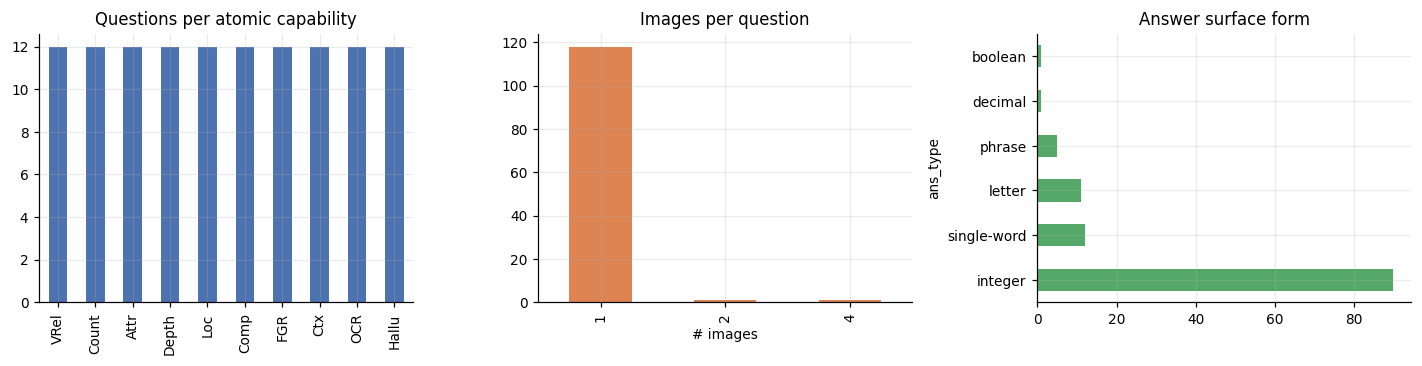

§5  ONE EXEMPLAR PER CAPABILITY


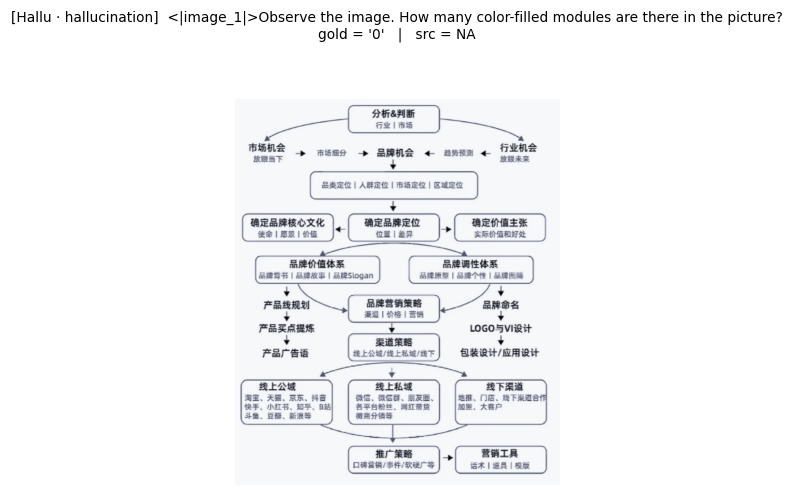

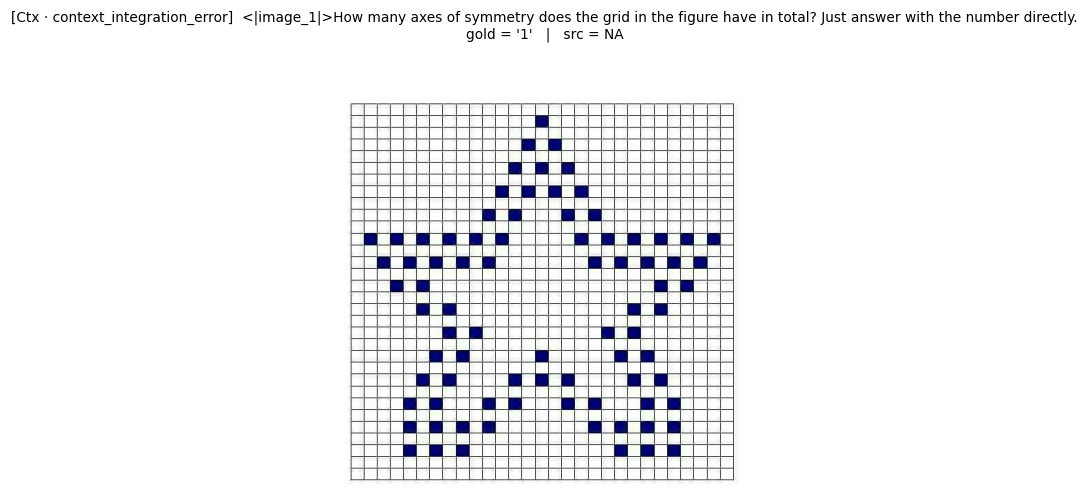

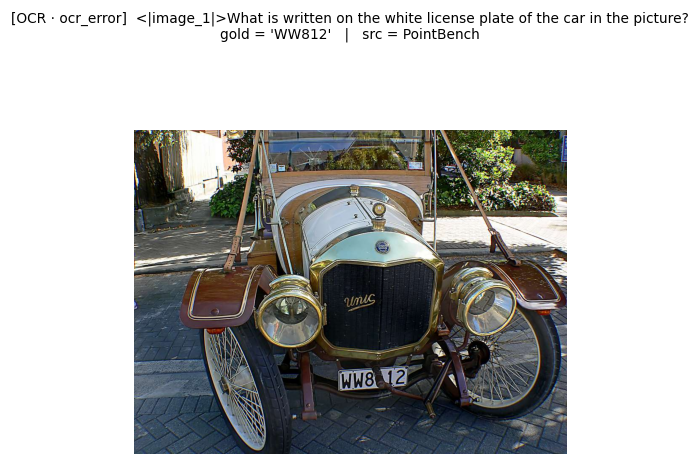

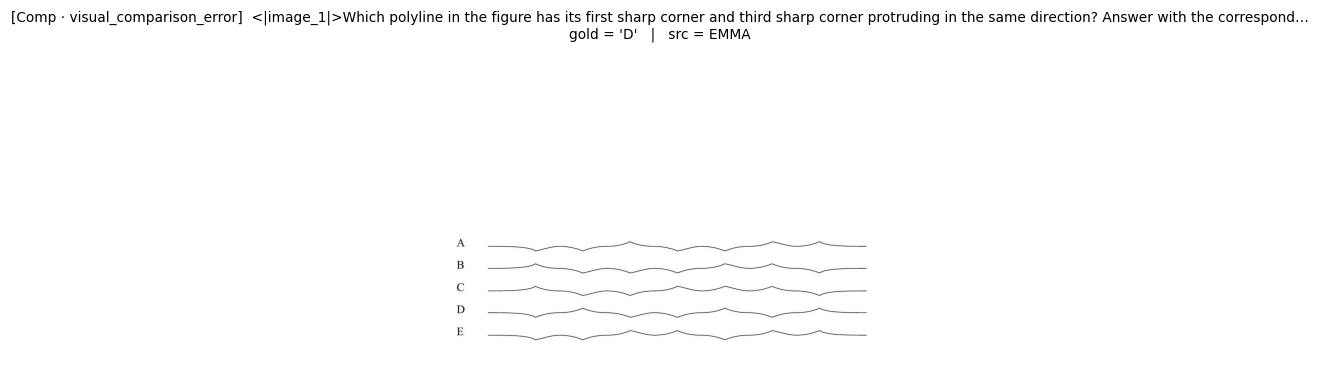

[judge] self-test: 9/9 passed

[eval] backend = blind-prior on 120 questions
[eval] done in 0.0s

§9  RESULTS — blind-prior

OVERALL accuracy:   4.2%   95% CI [0.8, 8.3]   (n=120)
(card: no frontier model exceeds 60% overall)

-- per atomic capability --
 code               capability  n    acc     lo     hi
 Attr                attribute 12    8.3    0.0   25.0
 Comp               comparison 12    8.3    0.0   25.0
  Ctx   contextual integration 12    8.3    0.0   25.0
Depth               depth & 3D 12    8.3    0.0   25.0
 VRel          visual relation 12    8.3    0.0   25.0
Count                 counting 12    0.0    0.0    0.0
  FGR      fine-grained recog. 12    0.0    0.0    0.0
Hallu perception hallucination 12    0.0    0.0    0.0
  Loc             localization 12    0.0    0.0    0.0
  OCR                      OCR 12    0.0    0.0    0.0

-- difficulty slices --

  by img_bucket:
                n  acc%
img_bucket             
multi-image     2   0.0
single-image  118   4.2



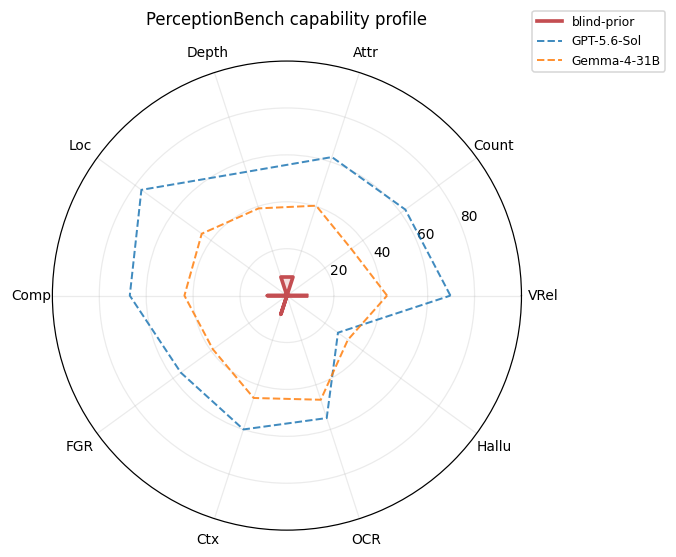

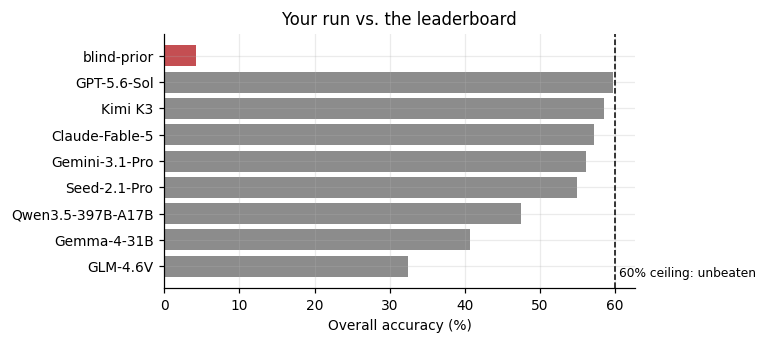


[export] /content/perceptionbench_out/predictions_blind-prior.jsonl
[export] /content/perceptionbench_out/per_capability_blind-prior.csv
[export] /content/perceptionbench_out/run_meta_blind-prior.json

DONE.  Next steps:
  1) CFG['BACKEND']='api'  + PB_API_KEY/PB_API_BASE/PB_API_MODEL  -> score a real MLLM
  2) CFG['BACKEND']='local' on a GPU runtime -> score an open 2-3B VLM
  3) CFG['JUDGE']='llm' -> reproduce the paper's LLM-as-judge protocol
  4) Raise N_PER_CATEGORY / MAX_SCAN, or LOAD_MODE='full' for all 3,000 rows
  5) Ablations worth running: crop-to-region vs. full image, image resolution
     sweep (MAX_IMAGE_SIDE 512/1024/2048), and CoT-on vs. CoT-off prompts


In [1]:
def run_eval(records, backend):
    print(f"\n[eval] backend = {backend.name} on {len(records)} questions")
    t0 = time.time()
    preds = backend.predict_batch(records)
    rows = []
    for rec, raw in zip(records, preds):
        if CFG["JUDGE"] == "llm" and CFG["API_KEY"]:
            ok, how = llm_judge(raw, rec["answer"], rec["problem"])
        else:
            ok, how = rule_judge(raw, rec["answer"], CFG["NUM_REL_TOL"])
        rows.append(dict(index=rec["index"], code=rec["code"], category=rec["category"],
                         source_bmk=rec["source_bmk"], n_images=rec["n_images"],
                         q_chars=rec["q_chars"], max_side=rec["max_side"],
                         ans_type=answer_type(rec["answer"]),
                         gold=rec["answer"], pred=extract_answer(raw),
                         raw=str(raw)[:2000], correct=ok, how=how))
    print(f"[eval] done in {time.time()-t0:.1f}s")
    return pd.DataFrame(rows)


def bootstrap_ci(vals, n_boot=4000, seed=0):
    a = np.asarray(vals, dtype=float)
    if a.size == 0:
        return (float("nan"), float("nan"))
    rng = np.random.default_rng(seed)
    means = a[rng.integers(0, a.size, (n_boot, a.size))].mean(axis=1)
    return tuple(np.percentile(means, [2.5, 97.5]) * 100)


def report(res, label):
    print("\n" + "=" * 78)
    print(f"§9  RESULTS — {label}")
    print("=" * 78)
    lo, hi = bootstrap_ci(res.correct)
    print(f"\nOVERALL accuracy: {res.correct.mean()*100:5.1f}%   "
          f"95% CI [{lo:.1f}, {hi:.1f}]   (n={len(res)})")
    print("(card: no frontier model exceeds 60% overall)\n")

    print("-- per atomic capability --")
    tab = []
    for code, g in res.groupby("code"):
        l, h = bootstrap_ci(g.correct)
        tab.append(dict(code=code, capability=CODE_FULL.get(code, code),
                        n=len(g), acc=g.correct.mean() * 100, lo=l, hi=h))
    t = pd.DataFrame(tab).sort_values("acc", ascending=False)
    print(t.to_string(index=False, float_format=lambda x: f"{x:6.1f}"))

    print("\n-- difficulty slices --")
    res = res.copy()
    res["img_bucket"] = np.where(res.n_images > 1, "multi-image", "single-image")
    res["res_bucket"] = pd.cut(res.max_side, [0, 800, 1600, 10**6],
                               labels=["<800px", "800-1600px", ">1600px"])
    for col in ["img_bucket", "res_bucket", "ans_type"]:
        s = res.groupby(col, observed=True).correct.agg(["size", "mean"])
        s["mean"] = (s["mean"] * 100).round(1)
        print(f"\n  by {col}:\n{s.rename(columns={'size':'n','mean':'acc%'}).to_string()}")

    print("\n-- judge decision breakdown --")
    print(res.how.value_counts().to_string())

    errs = res[res.correct == 0]
    if len(errs):
        print("\n-- sample failures --")
        for _, r in errs.head(5).iterrows():
            print(f"  [{r.code}] gold={r.gold!r:>14}  pred={r['pred']!r:>20}  ({r.how})")
    return t


BACKEND = make_backend()
RES = run_eval(RECORDS, BACKEND)
PER_CAP = report(RES, BACKEND.name)


LEADERBOARD = {
    "GPT-5.6-Sol":      [59.7, 69.7, 62.4, 62.1, 55.5, 76.7, 67.0, 55.9, 60.0, 54.9, 26.9],
    "Kimi K3":          [58.5, 68.2, 59.7, 59.4, 52.4, 70.3, 59.1, 55.9, 53.3, 61.2, 41.7],
    "Claude-Fable-5":   [57.2, 58.5, 52.9, 60.9, 51.5, 70.4, 56.1, 51.6, 59.8, 64.3, 45.0],
    "Gemini-3.1-Pro":   [56.2, 58.8, 56.9, 61.8, 50.0, 52.7, 61.7, 54.8, 61.2, 64.3, 40.6],
    "Seed-2.1-Pro":     [55.0, 57.6, 51.2, 58.2, 43.6, 50.0, 59.5, 56.6, 60.4, 66.7, 49.8],
    "Qwen3.5-397B-A17B":[47.5, 55.2, 49.1, 53.0, 44.6, 46.7, 49.8, 44.8, 50.2, 52.9, 26.9],
    "Gemma-4-31B":      [40.7, 42.7, 33.9, 40.3, 39.1, 44.9, 43.7, 39.0, 45.9, 46.7, 32.1],
    "GLM-4.6V":         [32.5, 35.2, 31.8, 35.2, 29.1, 30.6, 34.8, 29.3, 33.7, 39.2, 26.9],
}
LB = pd.DataFrame(LEADERBOARD, index=["Overall"] + CODE_ORDER).T

print("\n" + "=" * 78)
print("§10  OFFICIAL LEADERBOARD (subset, accuracy %)")
print("=" * 78)
print(LB.to_string())
print("\nNote the structural finding from the card: Hallu is the weakest column "
      "almost everywhere,\nand models with near-identical Overall scores have "
      "very different capability profiles.")


def radar(per_cap_df, label, compare=("GPT-5.6-Sol", "Gemma-4-31B")):
    codes = [c for c in CODE_ORDER if c in set(per_cap_df.code)]
    if len(codes) < 3:
        print("[radar] need >=3 capabilities"); return
    vals = per_cap_df.set_index("code").acc.reindex(codes).fillna(0).tolist()
    ang = np.linspace(0, 2 * np.pi, len(codes), endpoint=False).tolist()
    close = lambda v: v + v[:1]
    fig, ax = plt.subplots(figsize=(6.4, 6.4), subplot_kw=dict(polar=True))
    ax.plot(close(ang), close(vals), lw=2.4, color="#C44E52", label=label)
    ax.fill(close(ang), close(vals), alpha=.18, color="#C44E52")
    for m in compare:
        if m in LB.index:
            v = LB.loc[m, codes].tolist()
            ax.plot(close(ang), close(v), lw=1.3, ls="--", alpha=.85, label=m)
    ax.set_xticks(ang)
    ax.set_xticklabels(codes)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80])
    ax.set_title("PerceptionBench capability profile", pad=24)
    ax.legend(loc="upper right", bbox_to_anchor=(1.32, 1.12), fontsize=8)
    plt.tight_layout(); plt.show()


if CFG["SHOW_PLOTS"]:
    radar(PER_CAP, BACKEND.name)
    fig, ax = plt.subplots(figsize=(7, 3.2))
    s = LB["Overall"].sort_values()
    ax.barh(s.index, s.values, color="#8C8C8C")
    ax.barh([BACKEND.name], [RES.correct.mean() * 100], color="#C44E52")
    ax.axvline(60, ls="--", c="k", lw=1)
    ax.text(60.5, -.4, "60% ceiling: unbeaten", fontsize=8)
    ax.set_xlabel("Overall accuracy (%)"); ax.set_title("Your run vs. the leaderboard")
    plt.tight_layout(); plt.show()


tag = re.sub(r"[^A-Za-z0-9_.-]", "_", BACKEND.name)
p_pred = os.path.join(CFG["OUT_DIR"], f"predictions_{tag}.jsonl")
p_cap  = os.path.join(CFG["OUT_DIR"], f"per_capability_{tag}.csv")
p_meta = os.path.join(CFG["OUT_DIR"], f"run_meta_{tag}.json")

with open(p_pred, "w") as f:
    for _, r in RES.iterrows():
        f.write(json.dumps(r.to_dict(), default=str) + "\n")
PER_CAP.to_csv(p_cap, index=False)
json.dump({"config": {k: v for k, v in CFG.items() if "KEY" not in k},
           "backend": BACKEND.name, "n_questions": len(RES),
           "rows_scanned": N_SCANNED,
           "overall_acc": float(RES.correct.mean() * 100),
           "ci95": list(bootstrap_ci(RES.correct)),
           "timestamp": time.strftime("%Y-%m-%dT%H:%M:%S")},
          open(p_meta, "w"), indent=2)

print(f"\n[export] {p_pred}\n[export] {p_cap}\n[export] {p_meta}")
print("\n" + "=" * 78)
print("DONE.  Next steps:")
print("  1) CFG['BACKEND']='api'  + PB_API_KEY/PB_API_BASE/PB_API_MODEL  -> score a real MLLM")
print("  2) CFG['BACKEND']='local' on a GPU runtime -> score an open 2-3B VLM")
print("  3) CFG['JUDGE']='llm' -> reproduce the paper's LLM-as-judge protocol")
print("  4) Raise N_PER_CATEGORY / MAX_SCAN, or LOAD_MODE='full' for all 3,000 rows")
print("  5) Ablations worth running: crop-to-region vs. full image, image resolution")
print("     sweep (MAX_IMAGE_SIDE 512/1024/2048), and CoT-on vs. CoT-off prompts")
print("=" * 78)